In [2]:
import numpy as np
import os
import librosa
import librosa.display
import json

In [3]:
def load_audio_files(path):
    audio_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".mp3"):
                audio_files.append(os.path.join(root, file))
    return audio_files

In [4]:
path = '/mnt/Aimir_HD/' 
collection = 'lastfm'
extra = 'audio'
song_files = os.path.join(path, collection, extra)
files = load_audio_files(song_files)
print(len(files))

68935


In [5]:
id = 3
song = files[id]
print(song)

#song = '/home/laura/aimir/boomy/audio/14065870.mp3'
id_file = song.split('/')[-1].split('.')[0]
song

/mnt/Aimir_HD/lastfm/audio/e76afceb6a10771d5b9b78a63ddad1ce.mp3


'/mnt/Aimir_HD/lastfm/audio/e76afceb6a10771d5b9b78a63ddad1ce.mp3'

In [7]:
import json
import glob
import re

# Build an index from audio id -> full audio path
audio_root = os.path.join(path, collection, extra)
file_index = {}
for f in files:  # you already built this with load_audio_files
    bid = os.path.splitext(os.path.basename(f))[0]
    file_index[bid] = f

metadata_dir = os.path.join(path, collection, 'metadata')

def split_artists(name):
    """Split on common separators."""
    # handles 'The Beatles', 'The Beatles & Friends', 'The Beatles, feat. X'
    parts = re.split(r'\s*(?:,|&|;|feat\.?|ft\.?)\s*', name, flags=re.I)
    return [p for p in parts if p]

def extract_artists(meta):
    """Return a list of artist strings from varying schema keys."""
    candidates = []
    for key in ('artist', 'artist_name', 'artistName', 'artist_names', 'artists', 'musicbrainz_artist', 'mb_artist'):
        if key in meta and meta[key]:
            val = meta[key]
            if isinstance(val, str):
                candidates.extend(split_artists(val))
            elif isinstance(val, list):
                for v in val:
                    if isinstance(v, str):
                        candidates.extend(split_artists(v))
                    elif isinstance(v, dict):
                        # common nested patterns
                        for k in ('name', 'artist', 'artist_name'):
                            if k in v and isinstance(v[k], str):
                                candidates.extend(split_artists(v[k]))
    # de-dup while preserving order
    seen = set()
    out = []
    for c in candidates:
        c_norm = c.strip()
        if c_norm and c_norm.lower() not in seen:
            out.append(c_norm)
            seen.add(c_norm.lower())
    return out

def is_beatles(name):
    n = name.strip().lower()
    # allow exact 'the beatles' or 'beatles', also tolerate leading 'the '
    return n == 'the beatles' or n == 'beatles'

matches = []
# iterate metadata files
for meta_path in glob.iglob(os.path.join(metadata_dir, '*.json')):
    song_id = os.path.splitext(os.path.basename(meta_path))[0]
    try:
        with open(meta_path, 'r', encoding='utf-8') as jf:
            meta = json.load(jf)
    except Exception as e:
        # skip unreadable or malformed files
        continue

    artists = extract_artists(meta)
    if any(is_beatles(a) for a in artists):
        title = meta.get('title') or meta.get('track') or meta.get('name') or '(unknown title)'
        audio_path = file_index.get(song_id, '(audio file not found)')
        matches.append({
            'id': song_id,
            'title': title,
            'artists': artists,
            'audio': audio_path,
            'metadata': meta_path
        })

# Report
print(f'Found {len(matches)} Beatles matches.')
if matches:
    for m in matches:
        print("------------------------------------------------")
        print('  ', m['id'], '-', m['title'], 'by', ', '.join(m['artists']))
        # Show details of the first match
        print('  id      :', m['id'])
        print('  title   :', m['title'])
        print('  artists :', ', '.join(m['artists']))
        print('  audio   :', m['audio'])
        print('  metadata:', m['metadata'])

# If you want all ids:
beatles_ids = [m['id'] for m in matches]


Found 83 Beatles matches.
------------------------------------------------
   27090a9af7d04707b89a8ff00995ee6d - Hey Jude by The Beatles
  id      : 27090a9af7d04707b89a8ff00995ee6d
  title   : Hey Jude
  artists : The Beatles
  audio   : /mnt/Aimir_HD/lastfm/audio/27090a9af7d04707b89a8ff00995ee6d.mp3
  metadata: /mnt/Aimir_HD/lastfm/metadata/27090a9af7d04707b89a8ff00995ee6d.json
------------------------------------------------
   9f75a7206ce7ae2695922021247c8988 - Happiness Is a Warm Gun by The Beatles
  id      : 9f75a7206ce7ae2695922021247c8988
  title   : Happiness Is a Warm Gun
  artists : The Beatles
  audio   : /mnt/Aimir_HD/lastfm/audio/9f75a7206ce7ae2695922021247c8988.mp3
  metadata: /mnt/Aimir_HD/lastfm/metadata/9f75a7206ce7ae2695922021247c8988.json
------------------------------------------------
   cc2ad6e3d6346c916d930daf282ed68b - Magical Mystery Tour - Remastered 2009 by The Beatles
  id      : cc2ad6e3d6346c916d930daf282ed68b
  title   : Magical Mystery Tour - Remastere

In [17]:
path ="/mnt/Aimir_HD/lastfm/audio/"
meta = "/mnt/Aimir_HD/lastfm/metadata/"
id = "8cba002ec3d519b701241b51c7eb4fa9"
id = "36031c6ac135d8650d9fdc13140fc3bf"
song = os.path.join(path, id + '.mp3')

In [18]:
md = os.path.join(meta, id + '.json')
print(md)

with open(md) as json_file:
    data = json.load(json_file)
    
    # Calculate the maximum key length
    max_key_length = max(len(key) for key in data.keys())
    
    # Print each line with keys aligned
    for key in data:
        print(f"{key:{max_key_length}} : {data[key]}")

/mnt/Aimir_HD/lastfm/metadata/36031c6ac135d8650d9fdc13140fc3bf.json
id_dataset          : 36031c6ac135d8650d9fdc13140fc3bf
id_spotify          : 2Cy21RP95WjKPXjS343LoK
url_spotify_preview : https://p.scdn.co/mp3-preview/0b7f27e54b99170672e251a5fa65c6846ed8d9ec?cid=774b29d4f13844c495f206cafdad9c86
url_lastfm          : https://www.last.fm/music/The+Beatles/_/Come+Together
artist              : The Beatles
name                : Come Together
youtube_url         : https://www.youtube.com/watch?v=45cYwDMibGo
duration            : 258.193991


In [9]:
import formExtractor as fem
import importlib
importlib.reload(fem)
# Now plot
import plotMe
importlib.reload(plotMe)

# Create a formExtractor instance
formData = fem.formExtractor()
y, sr = librosa.load(song)

# Get beats reference
tempo, beats_reference = librosa.beat.beat_track(y=y, sr=sr)

chords = []

Note: Chord extraction method has been updated. Using empty chord dictionary for now.
Tempo: 172.265625
Threshold: 0.0


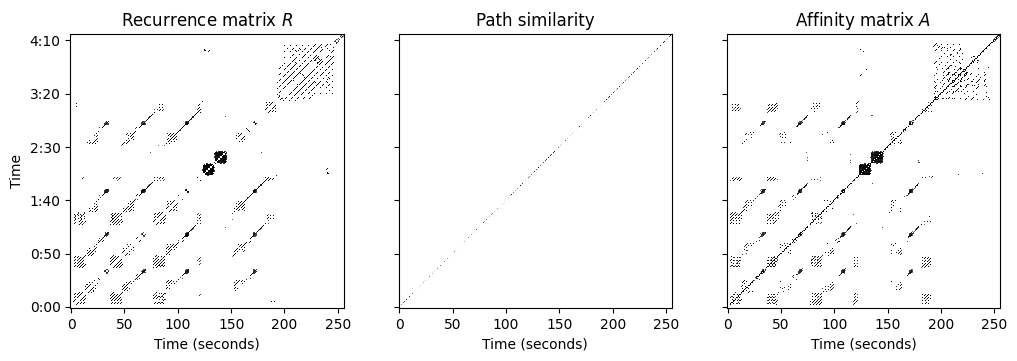

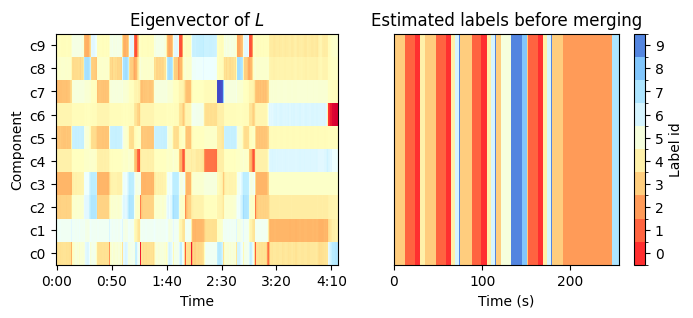

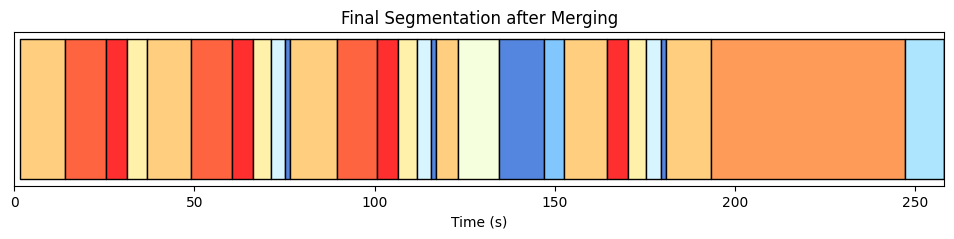

In [10]:
# Now run the optimized analysis with all required arguments
# color_options = ['RdYlBu',
#                 'RdYlBu_r',
#                 'RdBu_r',
#                 'coolwarm_r',
#                 'coolwarm',    
#                 ]


data_dict, color_aux = formData.optimize_song_structure(song, 
                                                        chords, 
                                                        beats_reference, 
                                                        K=10, 
                                                        min_duration=1.0, 
                                                        plot_it=True, 
                                                        colorformat='RdYlBu')

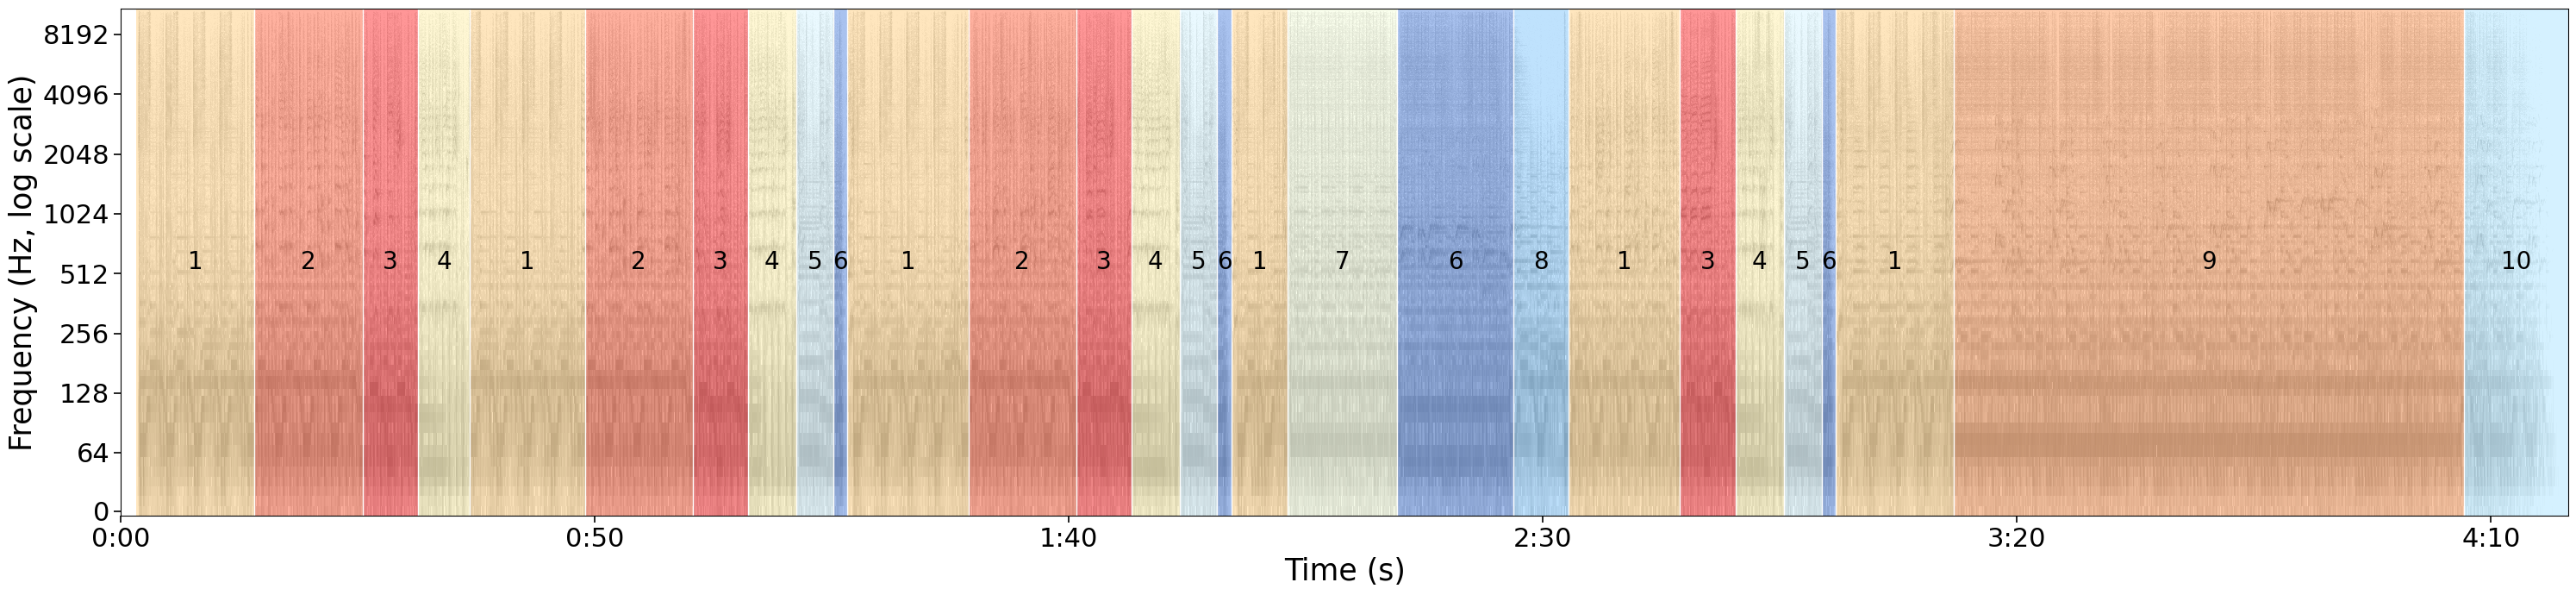

done!


In [11]:
# data_dict, color_aux = formData.optimize_song_structure(song, chords, beats_reference, K=10, min_duration=1.0, plot_it=False, colorformat="Blues")
plotMe.plotWaveform(
    formData.y, data_dict['sr'], data_dict['beats'],
    data_dict['bound_frames'], data_dict['bound_segments'],
    30, 7, 'Blues',
    label_colors=color_aux['label_colors'],
    segment_color_ids=color_aux['segment_color_ids'],
)

print("done!")

In [12]:
#listen to the audio
import IPython.display as ipd
ipd.Audio(song)
